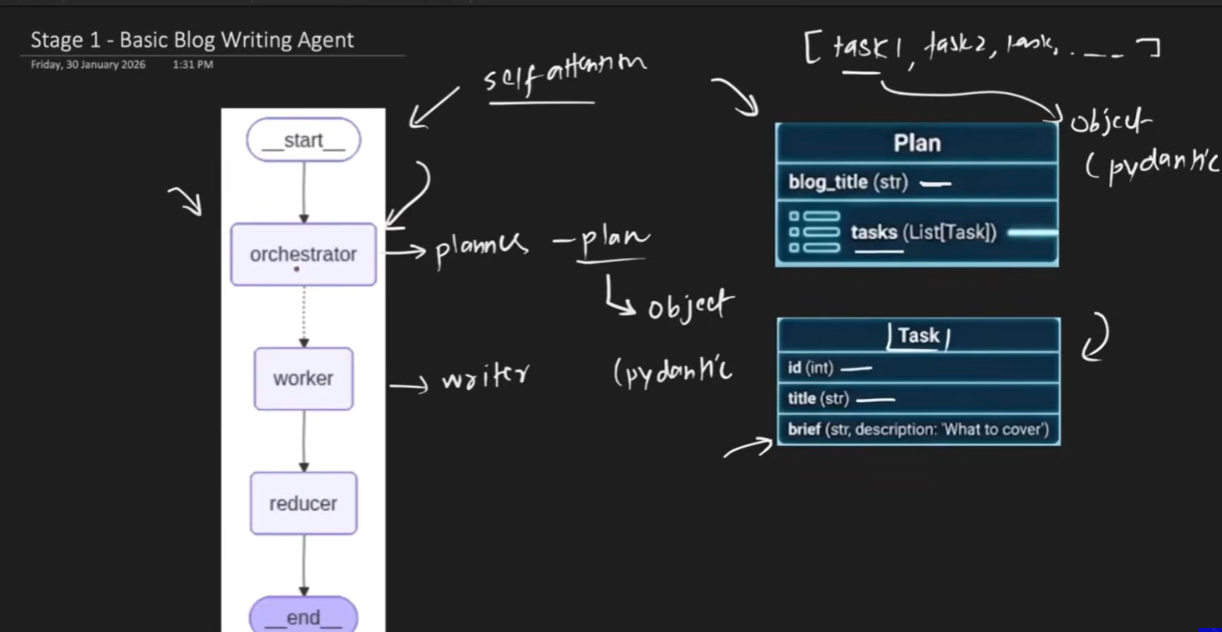

In [4]:
from langgraph.graph import StateGraph, START, MessagesState
from langchain_openai import ChatOpenAI
from groq import Groq
from langchain_groq import ChatGroq
from dotenv import load_dotenv
import os
from __future__ import annotations

import operator
from typing import TypedDict, List, Annotated

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
load_dotenv()

True

In [6]:
os.environ["LANGCHAIN_PROJECT"] = "blog writer"

In [11]:
class Task(BaseModel):
    '''
    Represents a writing task for a section of the blog post.

    Attributes:
        id: The unique identifier of the task.
        title: The title of the blog section.
        brief: A brief description of the section's content.
    '''
    id : int
    title: str = Field(..., description="The title of the blog post")
    brief: str = Field(..., description="The brief description of the blog post")

In [12]:
class Plan(BaseModel):
    '''
    Represents a plan for writing a blog post.
    A structured plan for generating a blog post.

    Attributes:
        blog_title: The title of the blog post.
        tasks: The ordered writing tasks required to complete the post.
    '''
    blog_title : str
    tasks : List[Task] = Field(..., description="The list of tasks to complete the blog post")


In [9]:
class State(TypedDict):
    '''
    State represents the shared state of the blog-generation workflow.

    Attributes:
        plan: The structured plan containing the blog title and writing tasks.
        topic: The topic of the blog post.
        sections: The generated blog sections accumulated during execution.
        final: The completed blog post.
    '''
    plan: Plan
    topic : str
    sections : Annotated[List[str],operator.add] = Field(description="The list of sections to be written for the blog post")
    final : str

In [13]:
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.3
)

In [14]:
def orchestrator(state: State) -> dict:
    """
    Generate a structured blog post plan based on the topic in the state.

    Args:
        state: The current workflow state containing the blog topic.

    Returns:
        A dictionary containing the generated blog plan.
    """

    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=(
                    "Create a blog plan with 5-7 sections on the following topic."
                )
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )
    return {"plan": plan}

In [15]:
def fanout(state: State):
    """
    Create worker tasks for each section in the generated blog plan.

    Args:
        state: The current workflow state containing the topic and blog plan.

    Returns:
        A list of Send objects that route each task to the worker node.
    """

    tasks = []

    for task in state["plan"].tasks:

        task_input = {
            "task": task,
            "topic": state["topic"],
            "plan": state["plan"]
        }

        tasks.append(
            Send(
                "worker",
                task_input
            )
        )

    return tasks

In [16]:
def worker(payload: dict) -> dict:
    """
    Generate one blog section from a writing task.

    Args:
        payload: A dictionary containing the task, topic, and blog plan.

    Returns:
        A dictionary containing the generated Markdown section.
    """

    # payload contains what we sent
    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    blog_title = plan.blog_title

    section_md = llm.invoke(
        [
            SystemMessage(content="Write one clean Markdown section."),
            HumanMessage(
                content=(
                    f"Blog: {blog_title}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Brief: {task.brief}\n\n"
                    "Return only the section content in Markdown."
                )
            ),
        ]
    ).content.strip()

    return {"sections": [section_md]}

In [25]:
from pathlib import Path

def reducer(state: State) -> dict:
    """Assemble the generated sections into a Markdown blog post and save it."""

    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"

    # ---- create output folder ----
    output_dir = Path("blogs_generated")
    output_dir.mkdir(parents=True, exist_ok=True)

    # ---- save file ----
    filename = title.lower().replace(" ", "_") + ".md"
    output_path = output_dir / filename

    output_path.write_text(
        final_md,
        encoding="utf-8"
    )

    return {
        "final": final_md
    }

In [26]:
graph = StateGraph(State)
graph.add_node("orchestrator", orchestrator)
graph.add_node("worker", worker)
graph.add_node("reducer", reducer)

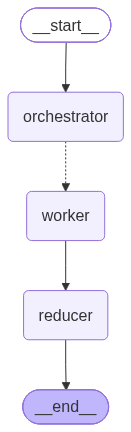

In [27]:
graph.add_edge(START, "orchestrator")
graph.add_conditional_edges("orchestrator", fanout, ["worker"]) ## gives no of workers needs to be generated
graph.add_edge("worker", "reducer")
graph.add_edge("reducer", END)

app = graph.compile()

app

Topic
  ↓
Orchestrator
  ↓
Create Plan
  ↓
Fan-out
  ↓
┌──────────┬──────────┬──────────┐
Worker 1   Worker 2   Worker 3   ... Worker 7
└──────────┴──────────┴──────────┘
              ↓
           Reducer
              ↓
        Final Markdown
              ↓
          .md file

In [28]:
output = app.invoke({"topic": "The Future of Artificial Intelligence in Medical Field"})

In [23]:
output

{'plan': Plan(blog_title='The Future of Artificial Intelligence in Everyday Life', tasks=[Task(id=1, title='Introduction: AI’s Growing Presence', brief='Set the stage by describing how AI has moved from research labs to daily routines, highlighting recent breakthroughs and why its future impact matters.'), Task(id=2, title='Smart Homes and Personal Assistants', brief='Explore AI‑driven devices—voice assistants, smart thermostats, security cameras—and how they’ll become more proactive, personalized, and interoperable.'), Task(id=3, title='Workplace Transformation', brief='Discuss AI tools for productivity, decision‑making, and collaboration, including automation of routine tasks, AI‑augmented creativity, and the shift in required skill sets.'), Task(id=4, title='Healthcare and Wellness', brief='Examine AI’s role in telemedicine, predictive health monitoring, personalized treatment plans, and mental‑health chatbots, emphasizing benefits and challenges.'), Task(id=5, title='Ethical, Priva